In [493]:
import warnings
warnings.filterwarnings('ignore')
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=14)
import seaborn as sns
import itertools
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn import metrics
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import calendar
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn import svm
from xgboost import XGBRegressor
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from xgboost import XGBClassifier

In [381]:
data = pd.read_csv('Train.csv')

In [382]:
test = pd.read_csv('Test.csv')

In [383]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [384]:
data.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [385]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [386]:
data.duplicated().sum()

0

### Relationship between variables with missing values and the dependent variable

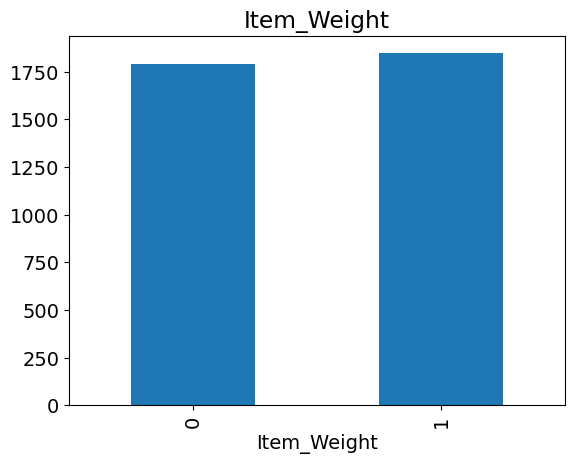

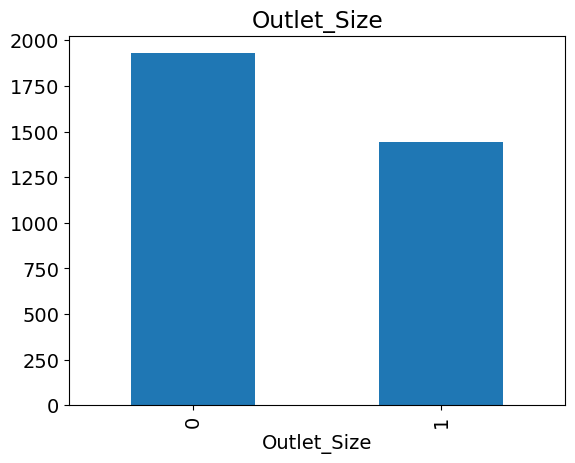

In [387]:
features_with_nan = ['Item_Weight','Outlet_Size']
for feature in features_with_nan:
    data1 = data.copy()
    # making a variable next to the original one that indicates 1 if the observation was missing and 0 if it was present
    data1[feature] = np.where(data1[feature].isna(),1,0)
    # plotting missing variables against median outlet sales for missing vs observed data
    data1.groupby(feature)['Item_Outlet_Sales'].median().plot.bar()
    plt.title(feature)
    plt.show();

### Relationship between numerical variables and dependent variable

In [388]:
numerical_features = [feature for feature in data.columns if data[feature].dtypes != 'O' and feature != 'Outlet_Establishment_Year']
numerical_features

['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']

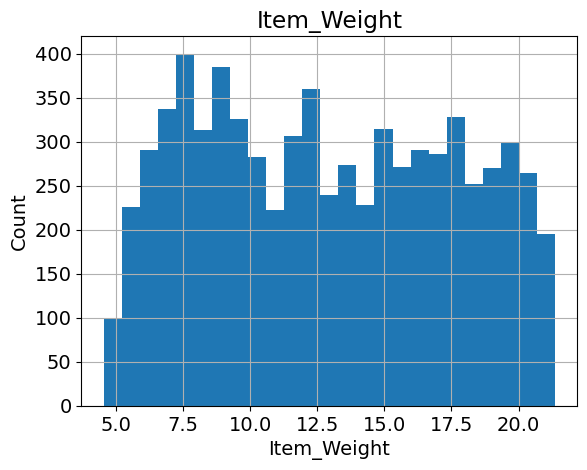

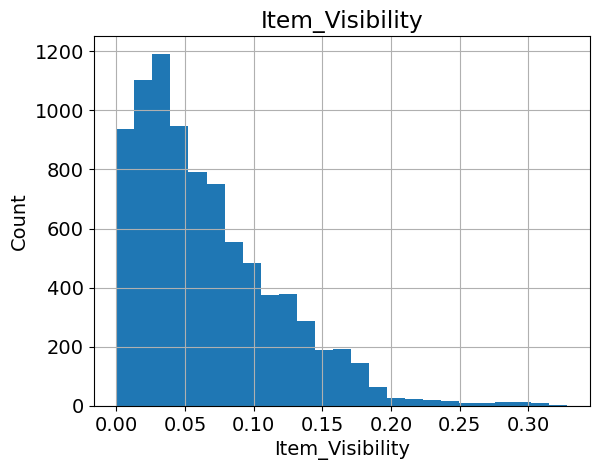

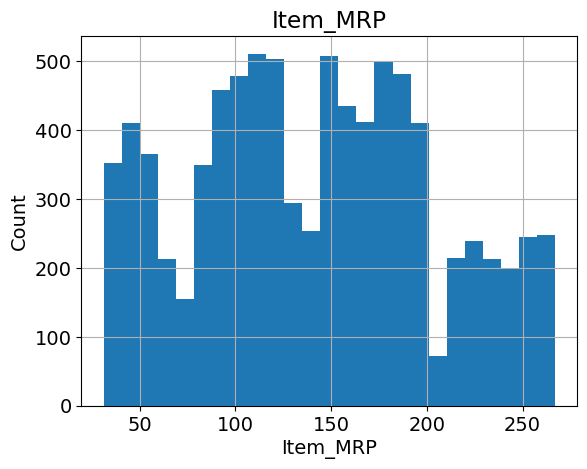

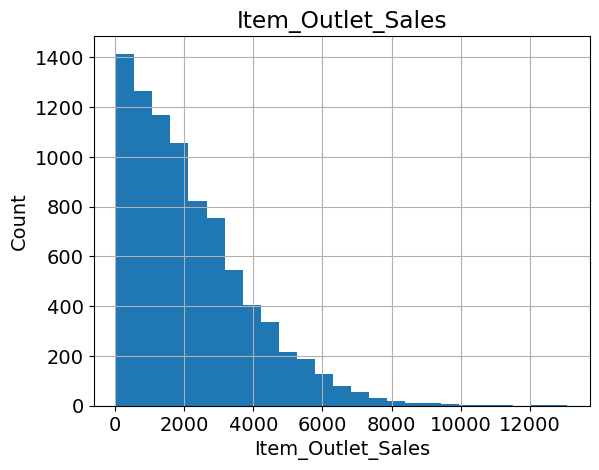

In [389]:
for feature in numerical_features:
    data1 = data.copy()
    data1[feature].hist(bins=25)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(feature)
    plt.show();

#### Relationship of temporal variable with dependent variable

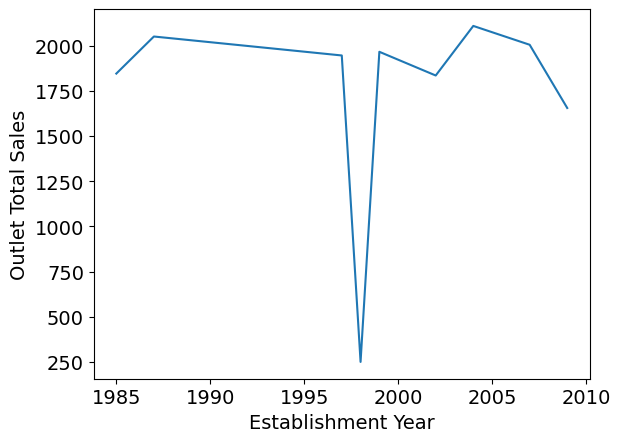

In [390]:
data.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].median().plot()
plt.xlabel('Establishment Year')
plt.ylabel('Outlet Total Sales')
plt.show();

In [391]:
data[data['Outlet_Establishment_Year'] == 1998]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
28,FDE51,5.925,Regular,0.161467,Dairy,45.5086,OUT010,1998,NaN,Tier 3,Grocery Store,178.4344
30,FDV38,19.250,Low Fat,0.170349,Dairy,55.7956,OUT010,1998,NaN,Tier 3,Grocery Store,163.7868
45,FDM39,6.420,LF,0.089499,Dairy,178.1002,OUT010,1998,NaN,Tier 3,Grocery Store,358.2004
65,FDC46,17.700,LF,0.195068,Snack Foods,185.4266,OUT010,1998,NaN,Tier 3,Grocery Store,184.4266
...,...,...,...,...,...,...,...,...,...,...,...,...
8400,NCE07,8.180,Low Fat,0.021977,Household,140.6154,OUT010,1998,NaN,Tier 3,Grocery Store,425.4462
8432,FDI16,14.000,Regular,0.227261,Frozen Foods,54.3640,OUT010,1998,NaN,Tier 3,Grocery Store,159.7920
8473,DRI47,14.700,Low Fat,0.035016,Hard Drinks,144.3128,OUT010,1998,NaN,Tier 3,Grocery Store,431.4384
8486,FDR20,20.000,Regular,0.000000,Fruits and Vegetables,46.4744,OUT010,1998,NaN,Tier 3,Grocery Store,45.2744


In [392]:
data['Outlet_Establishment_Year'].value_counts()

Outlet_Establishment_Year
1985    1463
1987     932
1999     930
1997     930
2004     930
2002     929
2009     928
2007     926
1998     555
Name: count, dtype: int64

In [393]:
data.loc[data['Outlet_Establishment_Year'] == 1998,'Outlet_Type'].value_counts()

Outlet_Type
Grocery Store    555
Name: count, dtype: int64

In [394]:
data['Outlet_Type'].value_counts()

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

In [395]:
data.loc[data['Outlet_Establishment_Year'] == 1998,'Outlet_Size']

3       NaN
28      NaN
30      NaN
45      NaN
65      NaN
       ... 
8400    NaN
8432    NaN
8473    NaN
8486    NaN
8509    NaN
Name: Outlet_Size, Length: 555, dtype: object

In [396]:
data['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [397]:
data.loc[data['Outlet_Establishment_Year'] == 1998,'Outlet_Location_Type'].value_counts()

Outlet_Location_Type
Tier 3    555
Name: count, dtype: int64

In [398]:
data.loc[data['Outlet_Establishment_Year'] == 1998,'Outlet_Identifier'].value_counts()

Outlet_Identifier
OUT010    555
Name: count, dtype: int64

### checking for outliers

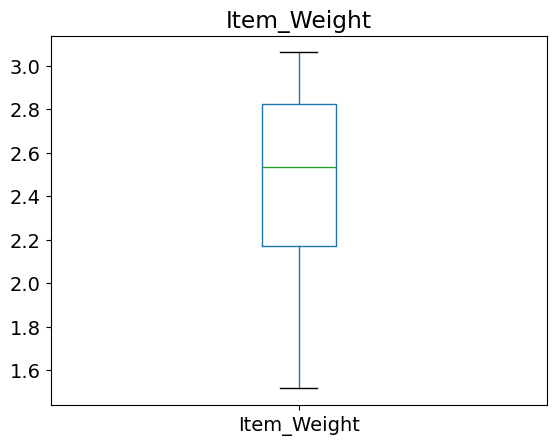

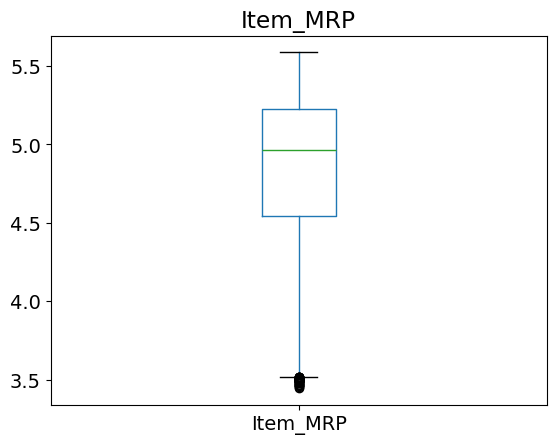

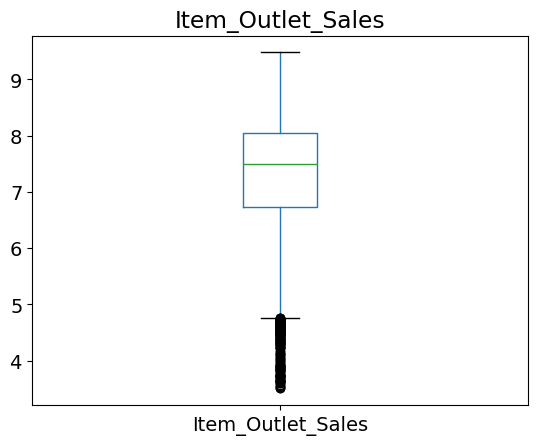

In [399]:
for feature in numerical_features:
    data1 = data.copy()
    if 0 in data1[feature].unique():
        pass
    else:
        data1[feature]=np.log(data1[feature])
        data1.boxplot(column=feature, grid=False)
        plt.title(feature)
        plt.show();

### Relationship between the categorical variables and the dependent variable

In [400]:
categorical_features = [feature for feature in data.columns if data1[feature].dtypes =='O']
categorical_features

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

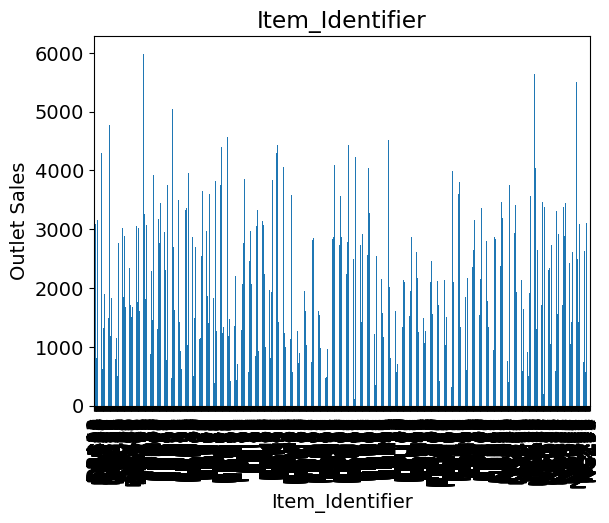

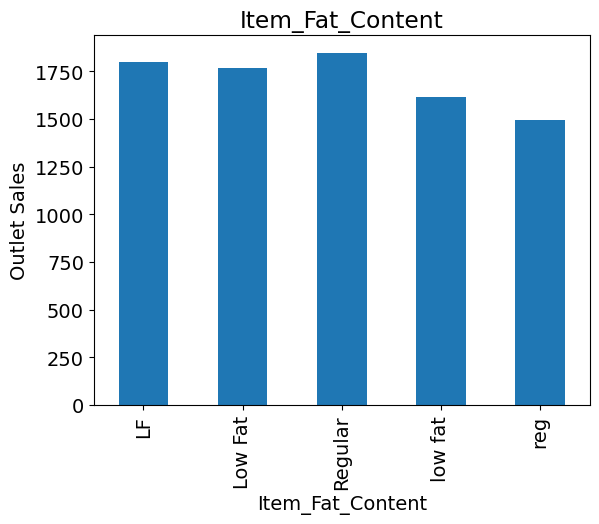

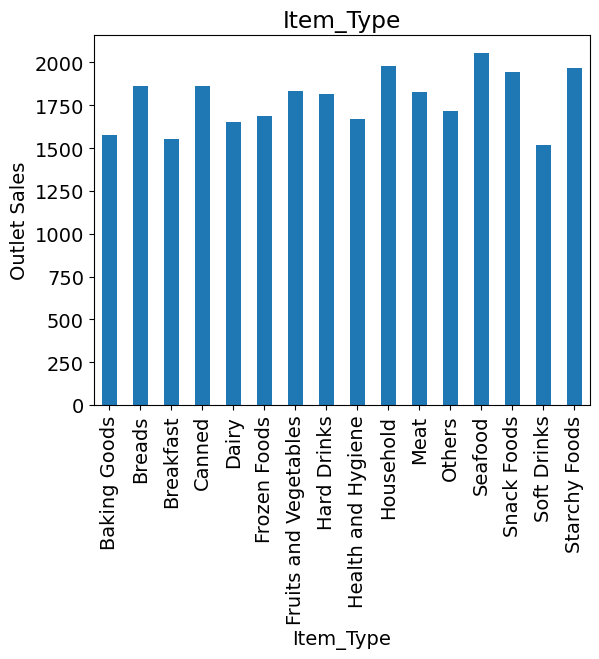

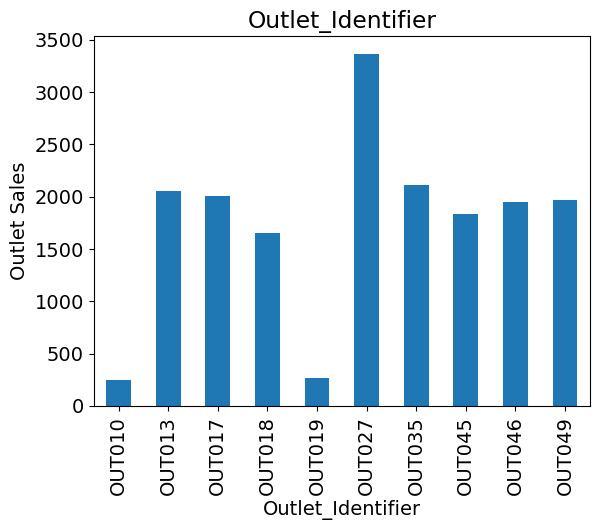

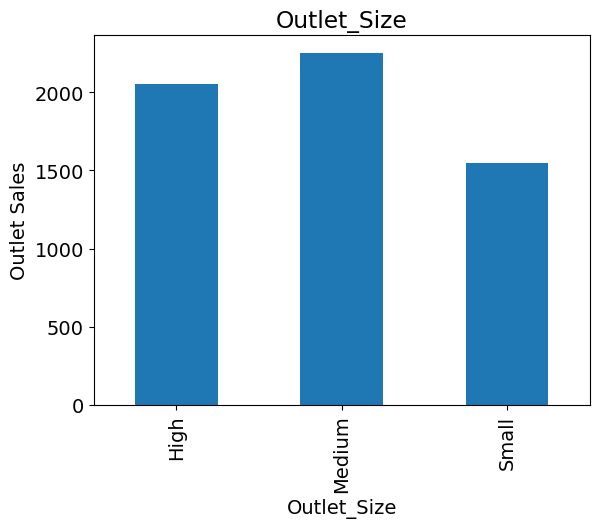

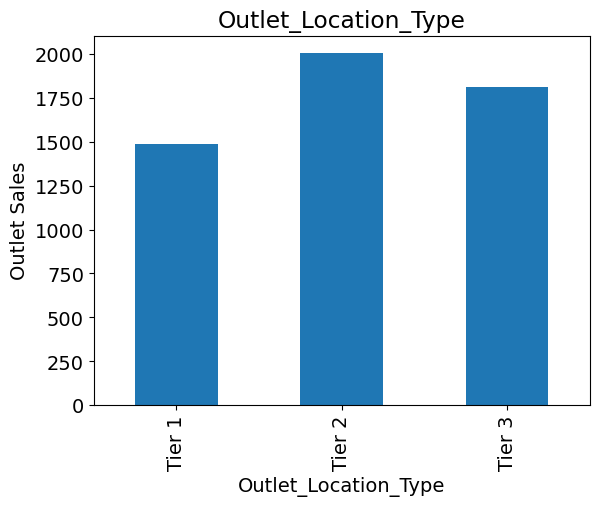

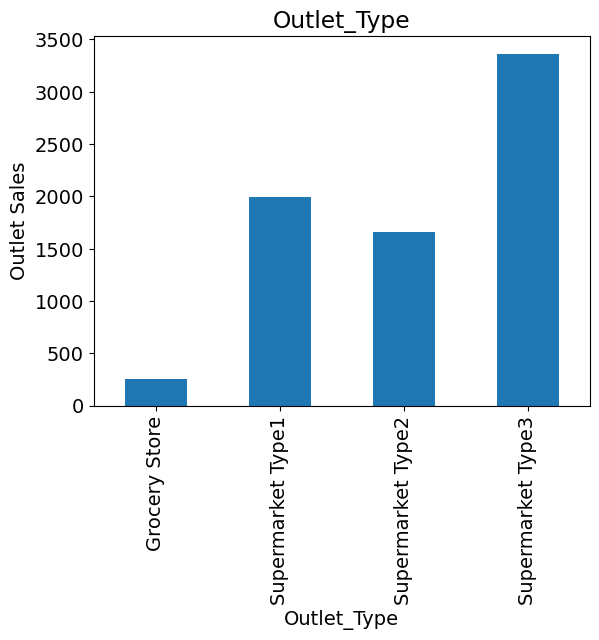

In [401]:
for feature in categorical_features:
    data1 = data.copy()
    data1.groupby(feature)['Item_Outlet_Sales'].median().plot.bar()
    plt.xlabel(feature)
    plt.ylabel('Outlet Sales')
    plt.title(feature)
    plt.show();

### Feature Engineering

In [402]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [403]:
data.shape

(8523, 12)

### Missing values

In [404]:
data['Outlet_Size'] = data['Outlet_Size'].fillna('Missing')

In [405]:
data['Item_Weight'] = data['Item_Weight'].fillna(data['Item_Weight'].mean())

In [406]:
data.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [407]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Missing,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


#### encoding the categorical variables

In [408]:
category_mappings = {}
for feature in categorical_features:
    labels_ordered = data.groupby([feature])['Item_Outlet_Sales'].mean().sort_values().index
    labels_ordered = {k:i for i,k in enumerate(labels_ordered,0)}
    data[feature] = data[feature].map(labels_ordered)
    category_mappings[feature] = labels_ordered

In [409]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,1545,9.30,3,0.016047,10,249.8092,7,1999,3,0,2,3735.1380
1,196,5.92,4,0.019278,2,48.2692,2,2009,3,1,1,443.4228
2,475,17.50,3,0.016760,7,141.6180,7,1999,3,0,2,2097.2700
3,1184,19.20,4,0.000000,13,182.0950,0,1998,0,1,0,732.3800
4,108,8.93,3,0.000000,11,53.8614,5,1987,2,1,2,994.7052


### Feature Scaling

In [410]:
feature_scale = [feature for feature in data.columns if feature not in ['Item_Outlet_Sales']]
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(data[feature_scale])

In [411]:
feature_scale

['Item_Identifier',
 'Item_Weight',
 'Item_Fat_Content',
 'Item_Visibility',
 'Item_Type',
 'Item_MRP',
 'Outlet_Identifier',
 'Outlet_Establishment_Year',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [412]:
scaled_data = pd.DataFrame(scaled_features, columns=feature_scale, index=data.index)

In [413]:
train_data = pd.concat([scaled_data, data['Item_Outlet_Sales']], axis=1)

In [414]:
train_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,0.991656,0.282525,0.75,0.048866,0.666667,0.927507,0.777778,0.583333,1.000000,0.0,0.666667,3735.1380
1,0.125802,0.081274,1.00,0.058705,0.133333,0.072068,0.222222,1.000000,1.000000,0.5,0.333333,443.4228
2,0.304878,0.770765,0.75,0.051037,0.466667,0.468288,0.777778,0.583333,1.000000,0.0,0.666667,2097.2700
3,0.759949,0.871986,1.00,0.000000,0.866667,0.640093,0.000000,0.541667,0.000000,0.5,0.000000,732.3800
4,0.069320,0.260494,0.75,0.000000,0.733333,0.095805,0.555556,0.083333,0.666667,0.5,0.666667,994.7052


In [415]:
train_data.to_csv('train_cleaned.csv', index=False)

### Feature Engineering for Test Data

In [416]:
test_data = pd.read_csv('test.csv')

In [417]:
test_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [418]:
test_data.isna().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [419]:
test_data['Item_Weight'] = test_data['Item_Weight'].fillna(test_data['Item_Weight'].mean())

In [420]:
test_data['Outlet_Size'] = test_data['Outlet_Size'].fillna('Missing')

In [421]:
test_data.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

#### encoding the categorical variables

In [422]:
categorical_features_test = [feature for feature in test_data.columns if test_data[feature].dtypes == 'O']
categorical_features_test

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [423]:
for feature in categorical_features_test:
     if feature in test_data.columns:
        test_data[feature] = test_data[feature].map(category_mappings[feature]).fillna(-1)

In [424]:
test_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,595,20.750000,3,0.007565,12,107.8622,7,1999,3,0,2
1,460,8.300000,0,0.038428,10,87.3198,6,2007,0,2,2
2,1502,14.600000,3,0.099575,0,241.7538,0,1998,0,1,0
3,572,7.315000,3,0.015388,12,155.0340,6,2007,0,2,2
4,1319,12.695633,4,0.118599,10,234.2300,9,1985,3,1,3


### Feature scaling

In [425]:
scaled_data = scaler.transform(test_data)

In [426]:
scaled_data

array([[0.38189987, 0.96427508, 0.75      , ..., 1.        , 0.        ,
        0.66666667],
       [0.29525032, 0.22298303, 0.        , ..., 0.        , 1.        ,
        0.66666667],
       [0.96405648, 0.59809467, 0.75      , ..., 0.        , 0.5       ,
        0.        ],
       ...,
       [0.5012837 , 0.32420363, 0.75      , ..., 0.        , 1.        ,
        0.66666667],
       [0.70346598, 0.63977374, 1.        , ..., 0.        , 1.        ,
        0.66666667],
       [0.51219512, 0.29443287, 1.        , ..., 0.        , 1.        ,
        0.66666667]])

In [427]:
test_data = pd.DataFrame(scaled_data, columns=feature_scale, index=test_data.index)

In [428]:
test_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,0.381900,0.964275,0.75,0.023036,0.800000,0.325012,0.777778,0.583333,1.0,0.0,0.666667
1,0.295250,0.222983,0.00,0.117018,0.666667,0.237819,0.666667,0.916667,0.0,1.0,0.666667
2,0.964056,0.598095,0.75,0.303221,0.000000,0.893316,0.000000,0.541667,0.0,0.5,0.000000
3,0.367137,0.164335,0.75,0.046860,0.800000,0.525233,0.666667,0.916667,0.0,1.0,0.666667
4,0.846598,0.484706,1.00,0.361153,0.666667,0.861381,1.000000,0.000000,1.0,0.5,1.000000


In [429]:
test_data.to_csv('test_cleaned.csv', index=False)

In [430]:
# Our data pred is done, we will now proceed with the model building

### Splitting the training set into train and validation

In [442]:
x_train = train_data.drop(['Item_Outlet_Sales'], axis=1)
y_train = train_data['Item_Outlet_Sales']

In [443]:
x_train,x_val,y_train,y_val = train_test_split(x_train, y_train, test_size = 0.4, random_state=1)

In [444]:
x_train.shape

(5113, 11)

In [445]:
x_val.shape

(3410, 11)

## Model Building

### Decision Tree Regressor

In [447]:
dtree = DecisionTreeRegressor(random_state=1)
param_dist = {'max_depth':np.arange(1,6,1),
              'min_samples_leaf':np.arange(1,10,1),
              'min_samples_split':np.arange(1,11,1),
              'max_leaf_nodes':np.arange(1,11,1),
              'min_impurity_decrease':np.arange(0.005,0.1,0.005)}
random_search_dt = RandomizedSearchCV(dtree, param_distributions=param_dist, n_iter=50, scoring ='neg_root_mean_squared_error',cv=5, random_state=1)
random_search_dt.fit(x_train, y_train)
best_model_dt = random_search_dt.best_estimator_
best_model_dt.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=4, max_leaf_nodes=10,
                      min_impurity_decrease=0.08, min_samples_leaf=6,
                      min_samples_split=8, random_state=1)

In [448]:
pred_train_dt = best_model_dt.predict(x_train)

In [450]:
mse_train_dt = ((y_train - pred_train_dt)**2).mean()
rmse_train_dt = np.sqrt(mse_train_dt)
rmse_train_dt

1035.8873713738121

#### predictions on the validation dataset

In [451]:
pred_val_dt = best_model_dt.predict(x_val)

In [452]:
mse_val_dt = ((y_val - pred_val_dt)**2).mean()
rmse_val_dt = np.sqrt(mse_val_dt)
rmse_val_dt

1047.8842406689457

In [494]:
model_results = pd.DataFrame({'Model':['Decision Tree (Train)','Decision Tree (Val)'],'RMSE':[rmse_train_dt, rmse_val_dt]})
model_results

,Model,RMSE
0,Decision Tree (Train),1035.887371
1,Decision Tree (Val),1047.884241


### Random Forest 

In [454]:
rf_model = RandomForestRegressor()
param_dist = {'n_estimators':np.arange(50,400,50),
              'max_depth':np.arange(1,12,1),
              'min_samples_leaf':np.arange(1,11,1),
              'min_samples_split':np.arange(1,11,1),
              'max_features':np.arange(0.1,0.8,0.1)}
random_search_rf = RandomizedSearchCV(rf_model, param_distributions=param_dist, cv=5, scoring='neg_root_mean_squared_error',random_state=1, n_iter=50)
random_search_rf.fit(x_train, y_train)
best_model_rf = random_search_rf.best_estimator_
best_model_rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=7, max_features=0.5, min_samples_leaf=5,
                      min_samples_split=5, n_estimators=200)

In [458]:
pred_train_rf = best_model_rf.predict(x_train)

In [459]:
mse_train_rf = ((y_train - pred_train_rf)**2).mean()
rmse_train_rf = np.sqrt(mse_train_rf)
rmse_train_rf

925.82451650486

#### making predictions on the validation dataset

In [460]:
pred_val_rf = best_model_rf.predict(x_val)

In [461]:
mse_val_rf = ((y_val - pred_val_rf)**2).mean()
rmse_val_rf = np.sqrt(mse_val_rf)
rmse_val_rf

989.6866141741341

In [495]:
rf_results = pd.DataFrame({'Model':['Random Forest (Train)','Random Forest (Val)'], 'RMSE':[rmse_train_rf, rmse_val_rf]})
model_results = pd.concat([model_results, rf_results], ignore_index=True)
model_results

,Model,RMSE
0,Decision Tree (Train),1035.887371
1,Decision Tree (Val),1047.884241
2,Random Forest (Train),925.824517
3,Random Forest (Val),989.686614


### KNN Regressor

In [463]:
KNN = KNeighborsRegressor(n_neighbors=5)
KNN.fit(x_train, y_train)

KNeighborsRegressor()

In [464]:
pred_train_knn = KNN.predict(x_train)

In [465]:
mse_train_knn = ((y_train - pred_train_knn)**2).mean()
rmse_train_knn = np.sqrt(mse_train_knn)
rmse_train_knn

892.480714890582

#### making predictions on the validation dataset

In [466]:
pred_val_knn = KNN.predict(x_val)

In [467]:
mse_val_knn = ((y_val - pred_val_knn)**2).mean()
rmse_val_knn = np.sqrt(mse_val_knn)
rmse_val_knn

1075.6427216313534

In [496]:
knn_results = pd.DataFrame({'Model':['KNN (Train)','KNN (Val)'], 'RMSE':[rmse_train_knn, rmse_val_knn]})
model_results = pd.concat([model_results, knn_results], ignore_index=True)
model_results

,Model,RMSE
0,Decision Tree (Train),1035.887371
1,Decision Tree (Val),1047.884241
2,Random Forest (Train),925.824517
3,Random Forest (Val),989.686614
4,KNN (Train),892.480715
5,KNN (Val),1075.642722


### SVM Regressor

In [470]:
svr = SVR()
svr.fit(x_train, y_train)

SVR()

In [471]:
pred_train_svr = svr.predict(x_train)

In [472]:
mse_train_svr = ((y_train - pred_train_svr)**2).mean()
rmse_train_svr = np.sqrt(mse_train_svr)
rmse_train_svr

1612.8559892669432

#### making predictions on the validation dataset

In [473]:
pred_val_svr = svr.predict(x_val)

In [474]:
mse_val_svr = ((y_val - pred_val_svr)**2).mean()
rmse_val_svr = np.sqrt(mse_val_svr)
rmse_val_svr

1599.9713140144877

In [497]:
svr_results = pd.DataFrame({'Model':['SVR (Train)','SVR (Val)'],'RMSE':[rmse_train_svr, rmse_val_svr]})
model_resutls = pd.concat([model_results, svr_results], ignore_index=True)
model_results

,Model,RMSE
0,Decision Tree (Train),1035.887371
1,Decision Tree (Val),1047.884241
2,Random Forest (Train),925.824517
3,Random Forest (Val),989.686614
4,KNN (Train),892.480715
5,KNN (Val),1075.642722


### XGBoost Regressor

In [485]:
xgb = XGBRegressor()
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0.5, 1.0, 1.5]
}
random_search_xgb = RandomizedSearchCV(xgb, param_distributions=param_dist, cv=5, scoring='neg_root_mean_squared_error',n_iter=50,random_state=1)
random_search_xgb.fit(x_train,y_train)
best_model_xgb = random_search_xgb.best_estimator_
best_model_xgb.fit(x_train, y_train)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.7,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.05, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=200, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0,
             reg_alpha=0.01, reg_lambda=1.0, ...)

In [486]:
pred_train_xgb = best_model_xgb.predict(x_train)

In [487]:
mse_train_xgb = ((y_train - pred_train_xgb)**2).mean()
rmse_train_xgb = np.sqrt(mse_train_xgb)
rmse_train_xgb

932.8723926715445

#### predicting on the validation set

In [488]:
pred_val_xgb = best_model_xgb.predict(x_val)

In [489]:
mse_val_xgb = ((y_val - pred_val_xgb)**2).mean()
rmse_val_xgb = np.sqrt(mse_val_xgb)
rmse_val_xgb

999.1823307496444

In [498]:
xgb_results = pd.DataFrame({'Model':['XGBRegressor (Train)','XGBRegressor (Val)'],'RMSE':[rmse_train_xgb, rmse_val_xgb]})
model_results = pd.concat([model_results, xgb_results], ignore_index=True)
model_results

,Model,RMSE
0,Decision Tree (Train),1035.887371
1,Decision Tree (Val),1047.884241
2,Random Forest (Train),925.824517
3,Random Forest (Val),989.686614
4,KNN (Train),892.480715
5,KNN (Val),1075.642722
6,XGBRegressor (Train),932.872393
7,XGBRegressor (Val),999.182331


### LightGBM Regressor

In [501]:
lgb = lgb.LGBMRegressor(objective='regression',random_state=1)
param_dist = {'n_estimators':[100,200,300,500],
              'learning_rate':[0.01,0.05,0.1,0.2],
              'max_depth':[-1,5,10,15],
              'num_leaves':[31,50,100],
              'min_child_samples':[5,10,20],
              'subsample':[0.6,0.8,1],
              'colsample_bytree':[0.6,0.8,1],
              'reg_alpha':[0, 0.1,0.5],
              'reg_lambda':[0,0.1,0.5]}
random_search_lgb = RandomizedSearchCV(lgb, param_distributions=param_dist, cv=5, random_state=1, scoring='neg_root_mean_squared_error',n_iter=50)
random_search_lgb.fit(x_train, y_train)
best_model_lgb = random_search_lgb.best_estimator_
best_model_lgb.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1043
[LightGBM] [Info] Number of data points in the train set: 4090, number of used features: 11
[LightGBM] [Info] Start training from score 2185.117183
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

LGBMRegressor(colsample_bytree=1, learning_rate=0.01, max_depth=5,
              n_estimators=300, objective='regression', random_state=1,
              reg_alpha=0.5, reg_lambda=0.5, subsample=1)

In [502]:
pred_train_lgb = best_model_lgb.predict(x_train)

In [503]:
mse_train_lgb = ((y_train - pred_train_lgb)**2).mean()
rmse_train_lgb = np.sqrt(mse_train_lgb)
rmse_train_lgb

932.2329462624978

### predictions on the validation dataset

In [504]:
pred_val_lgb = best_model_lgb.predict(x_val)

In [505]:
mse_val_lgb = ((y_val - pred_val_lgb)**2).mean()
rmse_val_lgb = np.sqrt(mse_val_lgb)
rmse_val_lgb

991.254322791543

In [506]:
lgb_results = pd.DataFrame({'Model':['LGB (Train)','LGB (Val)'],'RMSE':[rmse_train_lgb, rmse_val_lgb]})
model_results = pd.concat([model_results, lgb_results], ignore_index=True)
model_results

,Model,RMSE
0,Decision Tree (Train),1035.887371
1,Decision Tree (Val),1047.884241
2,Random Forest (Train),925.824517
3,Random Forest (Val),989.686614
4,KNN (Train),892.480715
5,KNN (Val),1075.642722
6,XGBRegressor (Train),932.872393
7,XGBRegressor (Val),999.182331
8,LGB (Train),932.232946
9,LGB (Val),991.254323


### Making predictions on the test data using LGB

In [508]:
pred_test = best_model_lgb.predict(test_data)

In [509]:
pred_test

array([1749.13891577, 1494.324516  ,  831.4666687 , ..., 2111.60227353,
       3214.07725408, 1984.58302517])

In [510]:
test = pd.DataFrame({'Item_Outlet_Sales':pred_test})
test.head()

,Item_Outlet_Sales
0,1749.138916
1,1494.324516
2,831.466669
3,1979.030371
4,5095.799826


In [512]:
test.to_csv('Test_Predictions.csv', index=False)